# Food Classification — NutritionTracker CV System
**Course:** ITAI 1378 | **Author:** Jemima Egwurube  
**Model:** EfficientNet-B0 fine-tuned on Food-101 (20-class subset)  
**Dataset:** [harishkumardatalab/food-image-classification-dataset](https://www.kaggle.com/datasets/harishkumardatalab/food-image-classification-dataset)

---
### Pipeline
```
Photo input → Resize & Normalize → EfficientNet-B0 → Top-3 Predictions → Nutrition Lookup → Result
```

## 1. Environment Setup

In [1]:
!pip install -q kaggle torchvision scikit-learn matplotlib seaborn pandas Pillow

import os, json, shutil, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE} | PyTorch: {torch.__version__}')

Device: cuda | PyTorch: 2.10.0+cu128


## 2. Dataset Loading

In [2]:
import os, json, shutil
from google.colab import userdata

# Retrieve Kaggle credentials from Colab secrets
KAGGLE_KEY = userdata.get('kaggleaccess_token') # Using the user's specified key name for the token

if KAGGLE_KEY:
    try:
        os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
        kaggle_json_path = os.path.expanduser('~/.kaggle/kaggle.json')
        with open(kaggle_json_path, 'w') as f:
            json.dump({"username": KAGGLE_USERNAME, "key": KAGGLE_KEY}, f)
        os.chmod(kaggle_json_path, 0o600)
        USE_KAGGLE = True
        print('Kaggle credentials configured from Colab secrets ✓')
    except Exception as e:
        USE_KAGGLE = False
        print(f'Error configuring Kaggle from secrets: {e}')
        print('Falling back to torchvision dataset.')
else:
    USE_KAGGLE = False
    print('Kaggle credentials (KAGGLE_USERNAME and kaggleaccess_token) not found in Colab secrets.')
    print('Please add them via the "🔑" icon in the left panel if you wish to use Kaggle.')
    print('Falling back to torchvision dataset.')


Error configuring Kaggle from secrets: name 'KAGGLE_USERNAME' is not defined
Falling back to torchvision dataset.


In [3]:
DATA_ROOT = Path('/content/food_data')

if USE_KAGGLE:
    !kaggle datasets download -d harishkumardatalab/food-image-classification-dataset -p /content --unzip
    # Auto-detect extracted folder
    skip = {'sample_data', 'food_data'}
    candidates = [p for p in Path('/content').iterdir()
                  if p.is_dir() and p.name not in skip]
    DATA_ROOT = candidates[0] if candidates else DATA_ROOT
    print(f'Dataset root: {DATA_ROOT}')
else:
    print('Using torchvision Food101 fallback (~5 GB download)...')
    DATA_ROOT = Path('/content/food101')
    DATA_ROOT.mkdir(exist_ok=True)

Using torchvision Food101 fallback (~5 GB download)...


In [4]:
if USE_KAGGLE:
    top = sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()])
    print('Top-level folders:', top[:6], '...')
    # Detect train/test split vs flat class folders
    has_split = 'train' in top or 'test' in top
    if has_split:
        TRAIN_DIR = DATA_ROOT / 'train'
        TEST_DIR  = DATA_ROOT / ('test' if (DATA_ROOT/'test').exists() else 'valid')
    else:
        TRAIN_DIR = DATA_ROOT
        TEST_DIR  = None
    CLASS_NAMES = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
    NUM_CLASSES  = len(CLASS_NAMES)
    print(f'Classes ({NUM_CLASSES}):', CLASS_NAMES)

## 3. Data Pipeline & Augmentation

In [5]:
IMG_SIZE   = 224
BATCH_SIZE = 32
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

val_tf = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])
print('Transforms ready ✓')

Transforms ready ✓


In [6]:
if USE_KAGGLE:
    if TEST_DIR:
        train_ds = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
        val_ds   = datasets.ImageFolder(TEST_DIR,  transform=val_tf)
    else:
        full_ds  = datasets.ImageFolder(TRAIN_DIR, transform=train_tf)
        n_train  = int(0.8 * len(full_ds))
        train_ds, val_ds = random_split(
            full_ds, [n_train, len(full_ds) - n_train],
            generator=torch.Generator().manual_seed(SEED))
        val_ds.dataset.transform = val_tf
        CLASS_NAMES = full_ds.classes
        NUM_CLASSES = len(CLASS_NAMES)
else:
    train_ds = datasets.Food101(DATA_ROOT, split='train', transform=train_tf, download=True)
    val_ds   = datasets.Food101(DATA_ROOT, split='test',  transform=val_tf,   download=True)
    CLASS_NAMES = train_ds.classes
    NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f'Train: {len(train_ds)} | Val: {len(val_ds)} | Classes: {NUM_CLASSES}')

Train: 75750 | Val: 25250 | Classes: 101


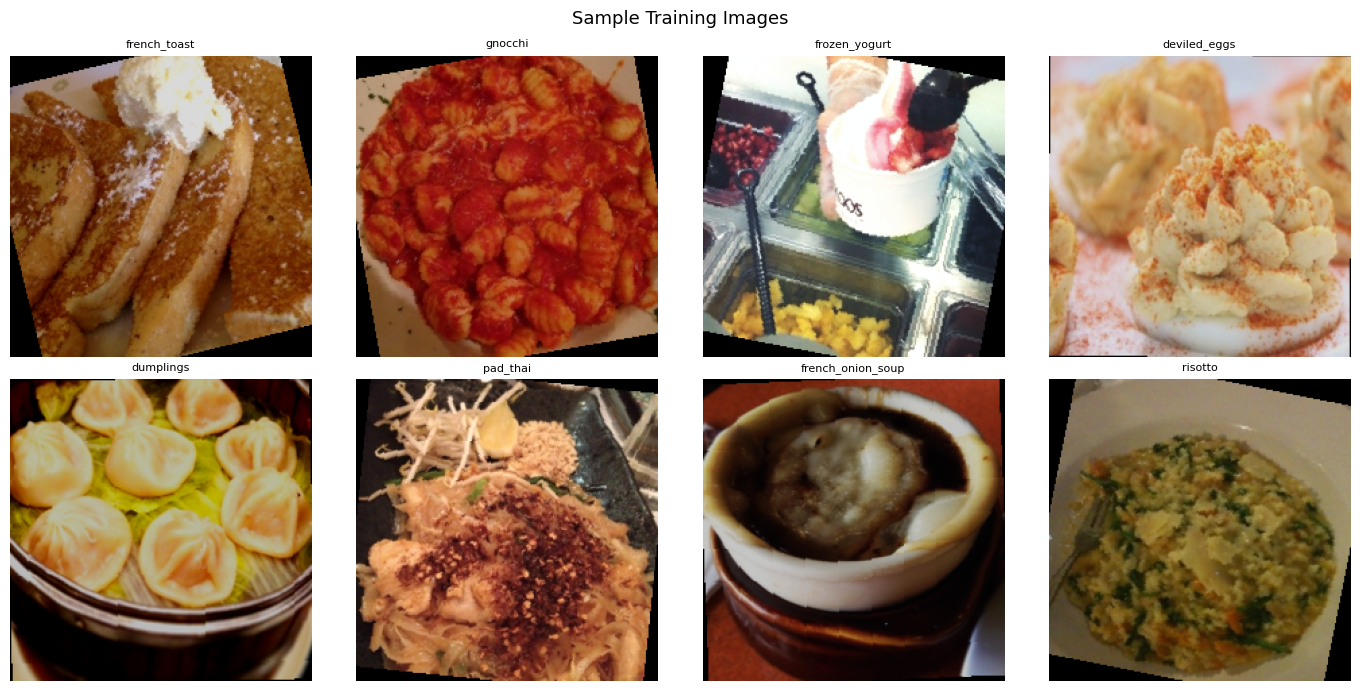

In [7]:
# Visualize sample training images
def imshow(t, title=''):
    img = t.numpy().transpose(1,2,0)
    img = np.clip(img * np.array(STD) + np.array(MEAN), 0, 1)
    plt.imshow(img); plt.title(title, fontsize=8); plt.axis('off')

imgs, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flat):
    plt.sca(ax); imshow(imgs[i], CLASS_NAMES[labels[i]])
plt.suptitle('Sample Training Images', fontsize=13)
plt.tight_layout()
os.makedirs('/content/results', exist_ok=True)
plt.savefig('/content/results/sample_images.png', dpi=120)
plt.show()

## 4. Model — EfficientNet-B0

In [8]:
def build_model(num_classes, freeze_backbone=True):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for p in model.features.parameters():
            p.requires_grad = False
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features, num_classes)
    )
    return model

model = build_model(NUM_CLASSES, freeze_backbone=True).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Params: {trainable:,} trainable / {total:,} total')

Params: 129,381 trainable / 4,136,929 total


## 5. Training (Two-Phase)

In [9]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    loss_sum, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        out  = model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        loss_sum += loss.item() * imgs.size(0)
        correct  += out.argmax(1).eq(labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total

@torch.no_grad()
def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    loss_sum, correct, total = 0.0, 0, 0
    preds, truths = [], []
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        out  = model(imgs)
        loss = criterion(out, labels)
        loss_sum += loss.item() * imgs.size(0)
        pred      = out.argmax(1)
        correct  += pred.eq(labels).sum().item()
        total    += imgs.size(0)
        preds.extend(pred.cpu().numpy())
        truths.extend(labels.cpu().numpy())
    return loss_sum / total, correct / total, preds, truths

In [10]:
# Phase 1 — train classifier head only (backbone frozen)
P1_EPOCHS = 5
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=P1_EPOCHS)

history = {'tl': [], 'vl': [], 'ta': [], 'va': []}
best_acc, best_wts = 0.0, None

print('=== Phase 1: Frozen backbone ===')
for ep in range(1, P1_EPOCHS + 1):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl, va, _, _ = eval_one_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()
    history['tl'].append(tl); history['vl'].append(vl)
    history['ta'].append(ta); history['va'].append(va)
    if va > best_acc:
        best_acc = va
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    print(f'Ep {ep:2d}/{P1_EPOCHS} | Train {ta:.4f} | Val {va:.4f} | LR {scheduler.get_last_lr()[0]:.6f}')

=== Phase 1: Frozen backbone ===
Ep  1/5 | Train 0.3591 | Val 0.5305 | LR 0.000905
Ep  2/5 | Train 0.4272 | Val 0.5656 | LR 0.000655
Ep  3/5 | Train 0.4495 | Val 0.5790 | LR 0.000345
Ep  4/5 | Train 0.4631 | Val 0.5821 | LR 0.000095
Ep  5/5 | Train 0.4714 | Val 0.5837 | LR 0.000000


In [11]:
 # Phase 2 — unfreeze all, fine-tune with lower LR
P2_EPOCHS = 10
for p in model.features.parameters():
    p.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=P2_EPOCHS, eta_min=1e-6)

print('=== Phase 2: Full fine-tune ===')
for ep in range(1, P2_EPOCHS + 1):
    tl, ta = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE)
    vl, va, _, _ = eval_one_epoch(model, val_loader, criterion, DEVICE)
    scheduler.step()
    history['tl'].append(tl); history['vl'].append(vl)
    history['ta'].append(ta); history['va'].append(va)
    if va > best_acc:
        best_acc = va
        best_wts = {k: v.clone() for k, v in model.state_dict().items()}
    print(f'Ep {ep:2d}/{P2_EPOCHS} | Train {ta:.4f} | Val {va:.4f}')

model.load_state_dict(best_wts)
torch.save({'model_state_dict': model.state_dict(), 'class_names': CLASS_NAMES,
            'num_classes': NUM_CLASSES, 'best_val_acc': best_acc},
           '/content/results/efficientnet_b0_food.pth')
print(f'\nBest Val Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%) | Model saved ✓')

=== Phase 2: Full fine-tune ===
Ep  1/10 | Train 0.6248 | Val 0.7814
Ep  2/10 | Train 0.7173 | Val 0.8143
Ep  3/10 | Train 0.7625 | Val 0.8332
Ep  4/10 | Train 0.7950 | Val 0.8419
Ep  5/10 | Train 0.8217 | Val 0.8492
Ep  6/10 | Train 0.8417 | Val 0.8553
Ep  7/10 | Train 0.8574 | Val 0.8583
Ep  8/10 | Train 0.8704 | Val 0.8584
Ep  9/10 | Train 0.8803 | Val 0.8591
Ep 10/10 | Train 0.8841 | Val 0.8627

Best Val Accuracy: 0.8627 (86.27%) | Model saved ✓


## 6. Evaluation

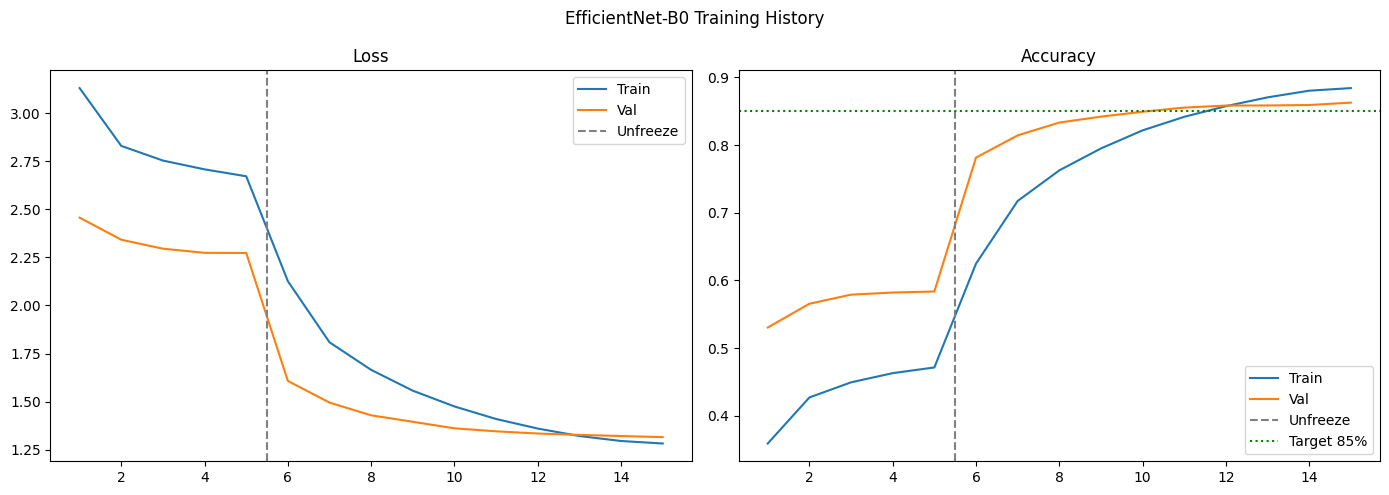

In [12]:
ep_range = range(1, len(history['tl']) + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep_range, history['tl'], label='Train'); ax1.plot(ep_range, history['vl'], label='Val')
ax1.axvline(P1_EPOCHS + .5, c='gray', ls='--', label='Unfreeze')
ax1.set_title('Loss'); ax1.legend()
ax2.plot(ep_range, history['ta'], label='Train'); ax2.plot(ep_range, history['va'], label='Val')
ax2.axvline(P1_EPOCHS + .5, c='gray', ls='--', label='Unfreeze')
ax2.axhline(0.85, c='green', ls=':', label='Target 85%')
ax2.set_title('Accuracy'); ax2.legend()
plt.suptitle('EfficientNet-B0 Training History')
plt.tight_layout()
plt.savefig('/content/results/training_curves.png', dpi=150); plt.show()

Final Top-1 Accuracy: 86.27%


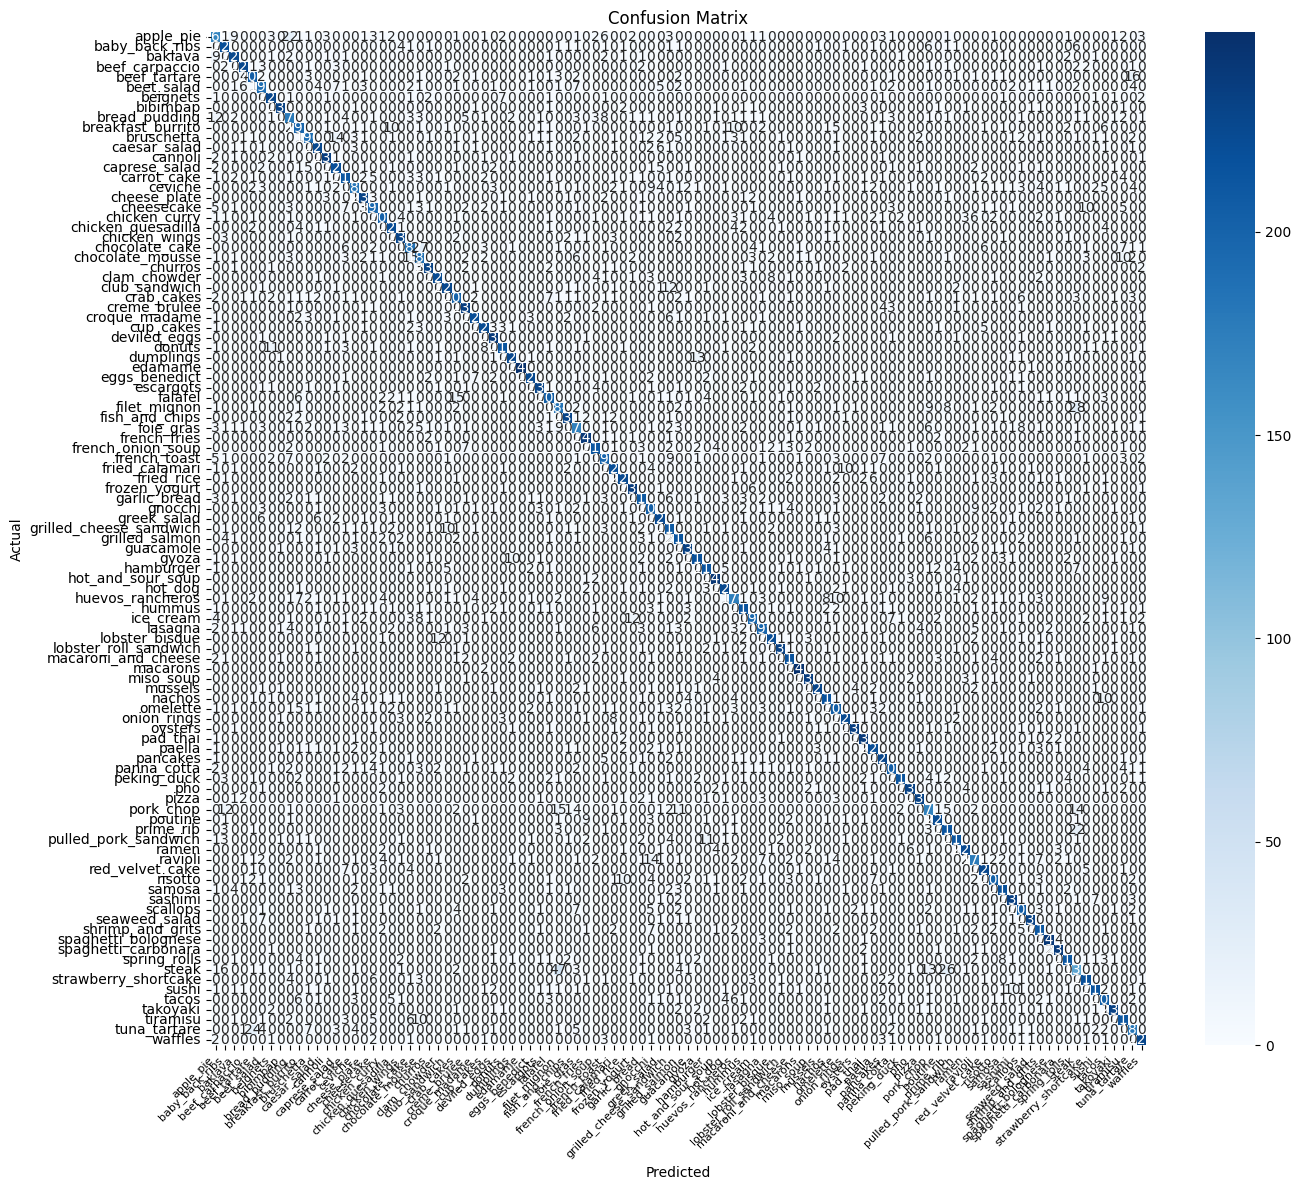

                         precision    recall  f1-score   support

              apple_pie      0.693     0.676     0.684       250
         baby_back_ribs      0.830     0.880     0.854       250
                baklava      0.866     0.904     0.885       250
         beef_carpaccio      0.912     0.908     0.910       250
           beef_tartare      0.821     0.824     0.822       250
             beet_salad      0.809     0.760     0.784       250
               beignets      0.884     0.916     0.900       250
               bibimbap      0.967     0.932     0.949       250
          bread_pudding      0.704     0.712     0.708       250
      breakfast_burrito      0.791     0.788     0.790       250
             bruschetta      0.848     0.760     0.802       250
           caesar_salad      0.866     0.908     0.887       250
                cannoli      0.922     0.944     0.933       250
          caprese_salad      0.837     0.880     0.858       250
            carrot_cake 

In [13]:
_, final_acc, all_preds, all_labels = eval_one_epoch(model, val_loader, criterion, DEVICE)
print(f'Final Top-1 Accuracy: {final_acc*100:.2f}%')

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.savefig('/content/results/confusion_matrix.png', dpi=150); plt.show()

report = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=3)
print(report)
with open('/content/results/classification_report.txt', 'w') as f:
    f.write(report)

## 7. Nutrition Lookup Table

In [14]:
NUTRITION = {
    'apple_pie':          {'display':'Apple Pie',          'kcal':296,'pro':2, 'carb':43,'fat':13,'serving':'1 slice (125g)'},
    'baby_back_ribs':     {'display':'Baby Back Ribs',     'kcal':305,'pro':24,'carb':0, 'fat':23,'serving':'3 ribs (130g)'},
    'baklava':            {'display':'Baklava',            'kcal':334,'pro':5, 'carb':29,'fat':23,'serving':'1 piece (78g)'},
    'beef_carpaccio':     {'display':'Beef Carpaccio',     'kcal':170,'pro':20,'carb':2, 'fat':9, 'serving':'85g'},
    'beef_tartare':       {'display':'Beef Tartare',       'kcal':196,'pro':22,'carb':3, 'fat':10,'serving':'100g'},
    'beet_salad':         {'display':'Beet Salad',         'kcal':130,'pro':4, 'carb':15,'fat':7, 'serving':'150g'},
    'beignets':           {'display':'Beignets',           'kcal':280,'pro':4, 'carb':35,'fat':14,'serving':'3 pc (80g)'},
    'bibimbap':           {'display':'Bibimbap',           'kcal':490,'pro':26,'carb':72,'fat':12,'serving':'1 bowl (400g)'},
    'bread_pudding':      {'display':'Bread Pudding',      'kcal':320,'pro':8, 'carb':52,'fat':10,'serving':'150g'},
    'breakfast_burrito':  {'display':'Breakfast Burrito',  'kcal':430,'pro':22,'carb':42,'fat':18,'serving':'1 burrito'},
    'bruschetta':         {'display':'Bruschetta',         'kcal':180,'pro':5, 'carb':24,'fat':7, 'serving':'2 pc (90g)'},
    'caesar_salad':       {'display':'Caesar Salad',       'kcal':358,'pro':10,'carb':16,'fat':30,'serving':'200g'},
    'cannoli':            {'display':'Cannoli',            'kcal':297,'pro':8, 'carb':29,'fat':17,'serving':'1 cannoli'},
    'caprese_salad':      {'display':'Caprese Salad',      'kcal':200,'pro':12,'carb':5, 'fat':15,'serving':'150g'},
    'carrot_cake':        {'display':'Carrot Cake',        'kcal':415,'pro':5, 'carb':55,'fat':20,'serving':'1 slice'},
    'ceviche':            {'display':'Ceviche',            'kcal':150,'pro':18,'carb':10,'fat':3, 'serving':'150g'},
    'cheesecake':         {'display':'Cheesecake',         'kcal':401,'pro':7, 'carb':35,'fat':26,'serving':'1 slice'},
    'cheese_plate':       {'display':'Cheese Plate',       'kcal':350,'pro':20,'carb':5, 'fat':28,'serving':'90g'},
    'chicken_curry':      {'display':'Chicken Curry',      'kcal':290,'pro':25,'carb':14,'fat':15,'serving':'250g'},
    'chicken_quesadilla': {'display':'Chicken Quesadilla', 'kcal':520,'pro':34,'carb':48,'fat':18,'serving':'220g'},
}

def get_nutrition(cls):
    key = cls.lower().replace(' ', '_').replace('-', '_')
    n = NUTRITION.get(key, {})
    return n if n else {'display': cls.replace('_',' ').title(),
                        'kcal':'?','pro':'?','carb':'?','fat':'?','serving':'?'}

# Test
print(get_nutrition('caesar_salad'))

{'display': 'Caesar Salad', 'kcal': 358, 'pro': 10, 'carb': 16, 'fat': 30, 'serving': '200g'}


## 8. Inference — Top-3 + Nutrition Panel

In [15]:
@torch.no_grad()
def predict(img_input, model, class_names, device):
    img = Image.open(img_input).convert('RGB') if isinstance(img_input, (str, Path)) else img_input.convert('RGB')
    t   = val_tf(img).unsqueeze(0).to(device)
    model.eval()
    probs = torch.softmax(model(t), dim=1)[0]
    top3p, top3i = probs.topk(3)
    return img, [{'rank': i+1, 'class': class_names[idx], 'conf': f'{p*100:.1f}%',
                  **get_nutrition(class_names[idx])}
                 for i, (p, idx) in enumerate(zip(top3p.cpu(), top3i.cpu()))]

def show_prediction(img_input, model, class_names, device, save_path=None):
    img, results = predict(img_input, model, class_names, device)
    fig, (ax_img, ax_tbl) = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios':[1,2]})
    ax_img.imshow(img); ax_img.axis('off')
    ax_img.set_title(f"Prediction: {results[0]['display']}", fontsize=13)
    rows = [[f"#{r['rank']} {r['display']}", r['conf'],
             f"{r['kcal']} kcal", f"{r['pro']}g", f"{r['carb']}g",
             f"{r['fat']}g", r['serving']] for r in results]
    ax_tbl.axis('off')
    tbl = ax_tbl.table(cellText=rows,
                       colLabels=['Food','Conf','Calories','Protein','Carbs','Fat','Serving'],
                       loc='center', cellLoc='center')
    tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.2, 2.0)
    ax_tbl.set_title('Top-3 Predictions + Nutrition', fontsize=12)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return results

print('Inference functions ready ✓')

Inference functions ready ✓


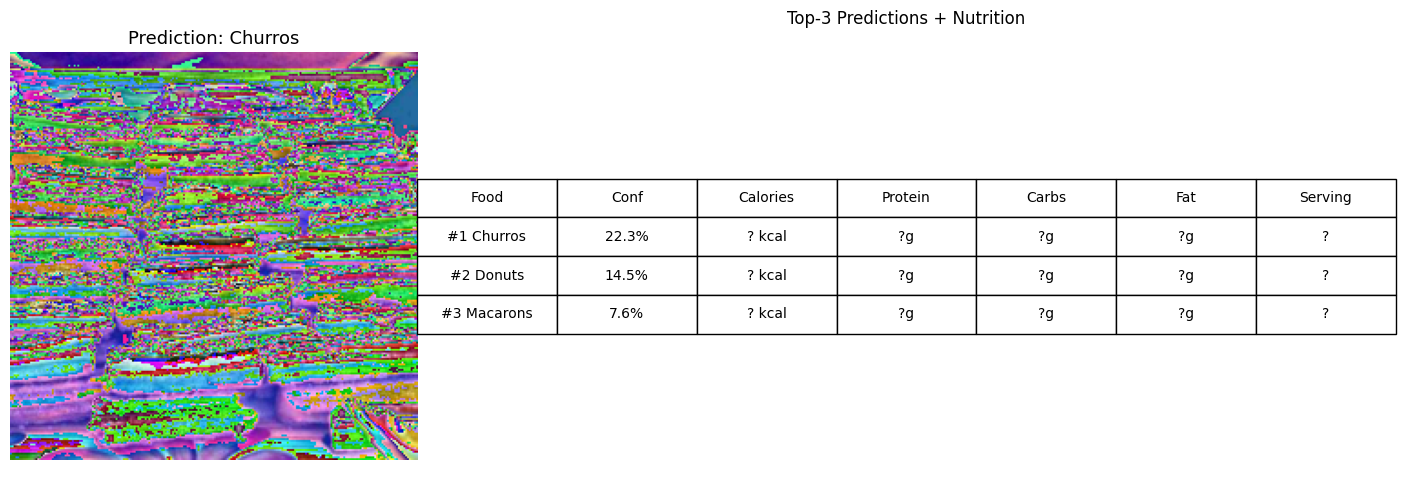

Ground truth: churros


In [16]:
# Demo on a random validation sample
if USE_KAGGLE and TEST_DIR:
    cls  = random.choice(CLASS_NAMES)
    imgs_in_class = list((TEST_DIR / cls).glob('*.jpg')) + list((TEST_DIR / cls).glob('*.jpeg'))
    sample = random.choice(imgs_in_class)
    results = show_prediction(sample, model, CLASS_NAMES, DEVICE,
                              save_path='/content/results/inference_example.png')
    print(f'Ground truth: {cls}')
else:
    imgs_b, labels_b = next(iter(val_loader))
    pil_img = transforms.ToPILImage()(imgs_b[0])
    results = show_prediction(pil_img, model, CLASS_NAMES, DEVICE,
                              save_path='/content/results/inference_example.png')
    print(f'Ground truth: {CLASS_NAMES[labels_b[0].item()]}')

Saving donut.jpg to donut.jpg


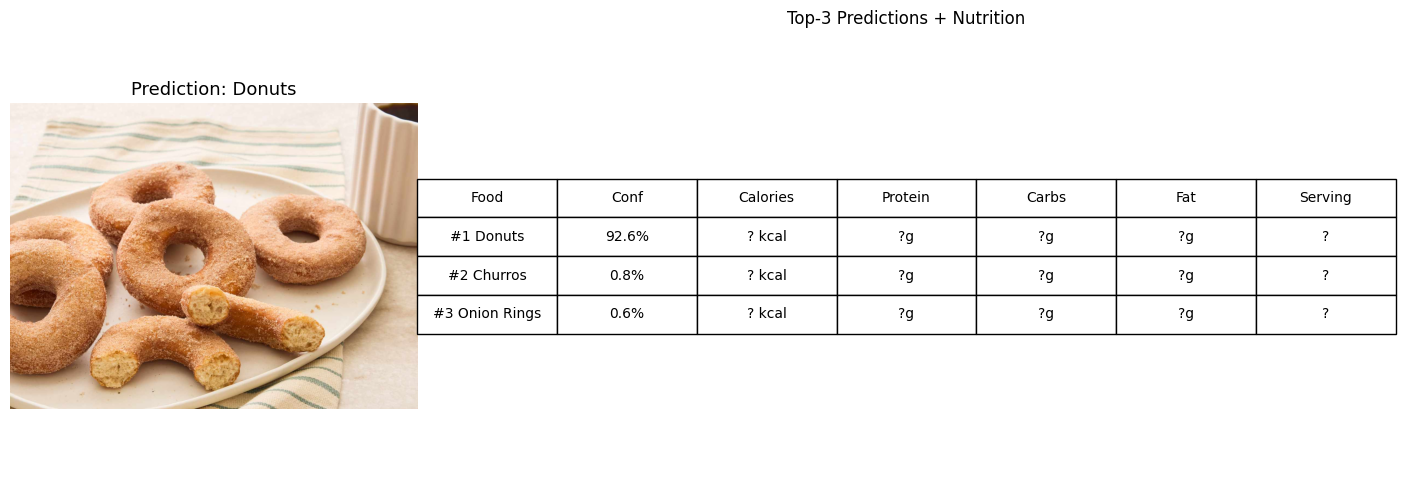

In [17]:
# Test with your own food photo
try:
    from google.colab import files
    uploaded = files.upload()
    for fname in uploaded:
        show_prediction(fname, model, CLASS_NAMES, DEVICE)
except Exception:
    print('Pass a file path to show_prediction() directly')

## 9. Results Summary & Export

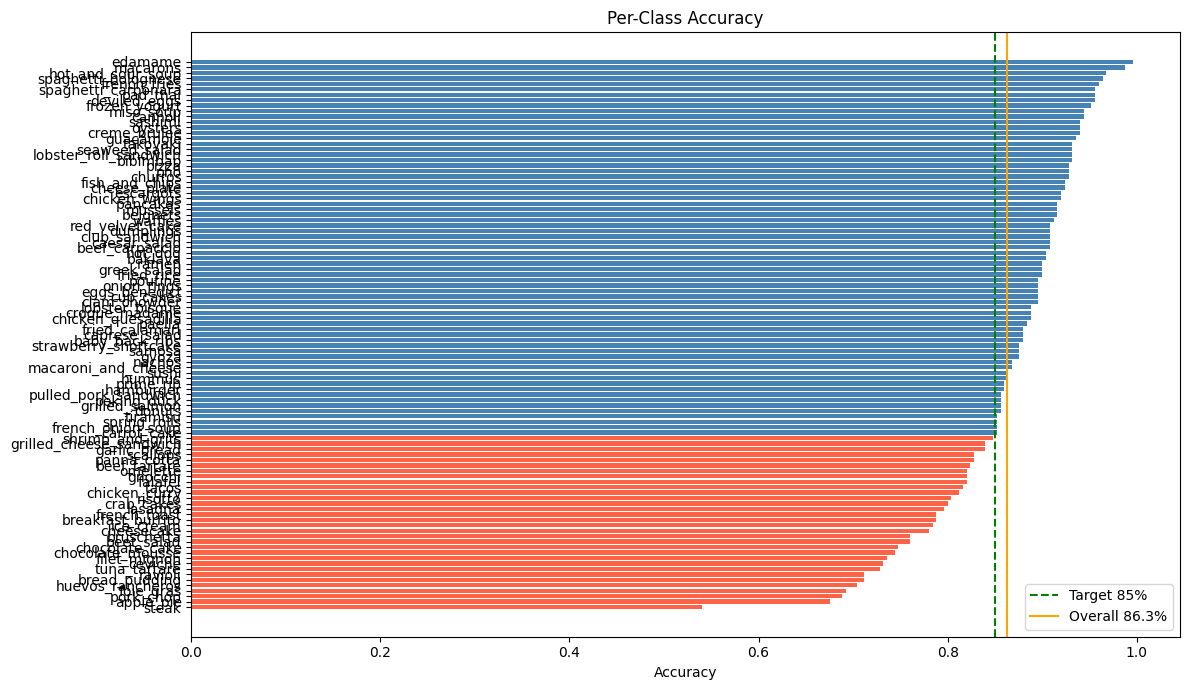


Top-1 Accuracy : 86.27%
Target         : ≥85.00%
Status         : ✅ PASSED


In [18]:
# Per-class accuracy bar chart
pc_correct = {c: 0 for c in CLASS_NAMES}
pc_total   = {c: 0 for c in CLASS_NAMES}
for pred, lbl in zip(all_preds, all_labels):
    c = CLASS_NAMES[lbl]
    pc_total[c]   += 1
    if pred == lbl: pc_correct[c] += 1
pc_acc = {c: pc_correct[c] / max(pc_total[c], 1) for c in CLASS_NAMES}

sc = sorted(pc_acc, key=pc_acc.get)
colors = ['tomato' if pc_acc[c] < 0.85 else 'steelblue' for c in sc]
plt.figure(figsize=(12, 7))
plt.barh(sc, [pc_acc[c] for c in sc], color=colors)
plt.axvline(0.85, c='green', ls='--', label='Target 85%')
plt.axvline(final_acc, c='orange', ls='-', label=f'Overall {final_acc*100:.1f}%')
plt.xlabel('Accuracy'); plt.title('Per-Class Accuracy')
plt.legend(); plt.tight_layout()
plt.savefig('/content/results/per_class_accuracy.png', dpi=150); plt.show()

# Save summary CSV
pd.DataFrame({'class': list(pc_acc), 'accuracy': list(pc_acc.values()),
              'correct': list(pc_correct.values()), 'total': list(pc_total.values())
             }).to_csv('/content/results/per_class_results.csv', index=False)

print(f'\nTop-1 Accuracy : {final_acc*100:.2f}%')
print(f'Target         : ≥85.00%')
print(f'Status         : {"✅ PASSED" if final_acc >= 0.85 else "⚠️  Below target — try more epochs or unfreeze earlier"}')

In [19]:
import zipfile
with zipfile.ZipFile('/content/results.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in Path('/content/results').rglob('*'):
        zf.write(f, f.relative_to('/content'))
try:
    from google.colab import files
    files.download('/content/results.zip')
    print('results.zip downloaded — extract into your repo results/ folder')
except Exception:
    print('Saved to /content/results.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

results.zip downloaded — extract into your repo results/ folder
